---
title: Fine-Tuning a Geospatial Foundation Model for UK Crop Classification
short_title: Prithvi-EO-2.0 Crop Map Classification
description: Tutorial notebook for fine-tuning Prithvi-EO-2.0. Data was derived from the UKCEH Land Cover® plus Crop maps and Sentinel-2.
  
date: 2026-07-31

github: https://github.com/NERC-CEH/geospatial-foundation-model-finetuning-lcm/tree/main

authors:
  - name: Benjamin Kenney Russell
    orcid: 0009-0003-0986-7006
    corresponding: true
    email: benjamin.kenney.russell@ut.ee
    affiliations:
      - name: National Capabilities for UK Challenges Internship
      
funding:
  - statement: This research was supported by NERC through the UKCEH National Capability for UK Challenges Programme.
    awards:
      - id: NE/Y006208/1
        name: UKCEH National Capability for UK Challenges Programme
---

<a href="https://colab.research.google.com/github/BenjaminKenRus/uk-crop-classification-prithvi/blob/main/toolbox_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prithvi-EO-2.0 UK Crop Map Classification

## Challenge and Methodological Approach Summary

Currently, UKCEH Land Cover® plus: Crops is updated using supervised learning methods that depend heavily on high-quality labelled training data. Much of this data is inherited from previous versions, which works well for existing classes. However, when new analytical needs arise, such as adding extra classes, there is a significant time and resource cost involved in generating sufficient new labelled data. Prithvi-EO-2.0 is a multi-temporal geospatial foundation model that is trained on millions of global time series samples from NASA's Harmonized Landsat and Sentinel-2 data archive.

This notebook demonstrates how to fine-tune Prithvi-2.0-EO using TerraTorch for a multi-temporal crop classification task. It covers setting up the environment, preparing the data using  a custom `CropDataModule`, configuring and training a semantic segmentation model, and evaluating its performance.

```{dropdown} Definitions
### Core Concepts & Frameworks

*   **Earth Observation (EO)**: The field of collecting and analyzing information about Earth's physical, chemical, and biological systems through remote sensing techniques, often using satellite imagery.
*   **Foundation Model**: A large, pre-trained deep learning model designed to perform a wide range of tasks. It learns general features from vast amounts of data and can be adapted (fine-tuned) for specific downstream applications.
*   **Prithvi foundation model**: A specific foundation model developed by IBM for Earth observation (EO) data. It learns features from satellite imagery and is designed to be fine-tuned for various geospatial tasks.
*   **TerraTorch**: An open-source Python library built on PyTorch that provides tools and functionalities specifically for working with geospatial and Earth observation data, facilitating the development and application of deep learning models, including foundation models like Prithvi.

### Data & Preprocessing

*   **Multi-temporal Classification**: A machine learning task that involves classifying land cover or objects by analyzing a sequence of satellite images taken over different time points (i.e., multiple timestamps). This helps to capture changes and temporal patterns.
*   **`DataModule` (PyTorch Lightning)**: A high-level abstraction in PyTorch Lightning that encapsulates all data-related logic for a deep learning project, including data loading, preprocessing, augmentation, and splitting into training, validation, and test sets.
*   **`CropDataModule`**: A specialized `DataModule` implementation within TerraTorch designed to handle the specific multi-temporal crop classification dataset used in this notebook.
*   **`batch_size`**: The number of samples processed together in one forward/backward pass during training.
*   **`num_workers`**: The number of subprocesses used for data loading to speed up the data fetching process.
*   **`data_root`**: The base directory path where the dataset files are stored.
*   **Transformations**: Operations applied to input data (e.g., images) for augmentation (to increase data variability) or preprocessing (e.g., normalization, resizing) before feeding them into the model.

*   **Spectral Bands**: Different ranges of electromagnetic radiation (wavelengths) captured by sensors (e.g., satellite imagery). Common bands include Blue, Green, Red, Near-Infrared (NIR), and Short-Wave Infrared (SWIR).

### Model Training & Evaluation

*   **Semantic Segmentation**: A computer vision task that involves classifying every pixel in an image into a predefined category. In this context, it means classifying each pixel in a satellite image as a particular crop type.
*   **Fine-tuning**: The process of taking a pre-trained model (like Prithvi) and continuing its training on a new, specific dataset for a related task. This often requires less data and computational resources than training from scratch.
*   **`Trainer` (PyTorch Lightning)**: The central object in PyTorch Lightning that orchestrates the entire training loop, including optimization, logging, checkpointing, and evaluation.
*   **`ModelCheckpoint`**: A PyTorch Lightning callback that automatically saves the model's weights during training, typically saving the best-performing model based on a monitored metric.
*   **`SemanticSegmentationTask`**: A specific task implementation within TerraTorch designed for semantic segmentation problems, providing an interface to define model architecture, loss, and metrics.
*   **`accelerator`**: Specifies the type of hardware used for training (e.g., 'gpu', 'cpu', 'tpu').
*   **`precision`**: Defines the numerical precision used for computations during training (e.g., `16-mixed` for mixed-precision training, which can speed up training and reduce memory usage).
*   **`max_epochs`**: The maximum number of times the entire training dataset will be passed through the model during training.
*   **`backbone`**: The feature extraction part of a deep learning model, typically a pre-trained convolutional neural network (CNN) or a Vision Transformer (ViT), which learns hierarchical representations of the input data.
*   **`decoder`**: In semantic segmentation models, the decoder takes the features extracted by the backbone and upsamples them to reconstruct an output image (segmentation mask) at the original input resolution.
*   **`head`**: The final layer(s) of a deep learning model that produce the task-specific output (e.g., class probabilities for classification, pixel-wise predictions for segmentation).
*   **`loss function` (`loss`)**: A mathematical function that quantifies the difference between the model's predictions and the true labels. The goal of training is to minimize this function.
*   **`Learning Rate (lr)`**: A hyperparameter that determines the step size at which an optimizer adjusts the model's weights during training.
*   **`Optimizer`**: An algorithm (e.g., Adam, SGD) used to adjust the weights and biases of a neural network to minimize the loss function.
*   **`freeze_backbone`, `freeze_decoder`**: Techniques used during fine-tuning where the weights of specific parts of the model (e.g., the backbone or decoder) are kept fixed and are not updated during the training process, often to preserve pre-trained knowledge.
*   **`TensorBoard`**: A web-based visualization tool provided by TensorFlow (and compatible with PyTorch Lightning) that allows tracking training metrics (loss, accuracy), visualizing model graphs, and analyzing embeddings.
*   **`Checkpoint`**: A saved state of a deep learning model at a particular point during training, including its architecture, weights, optimizer state, and other metadata. This allows for resuming training or loading the best model for inference.

## Importing Libraries and Loading Data

### Setup
1. In colab: Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"

This cell installs the `terratorch` library along with `gdown` (for downloading files from Google Drive) and `tensorboard` (for visualizing training metrics). It also ensures specific compatible versions of `torch`, `torchvision`, and `albumentations` are installed or uninstalled to meet `terratorch`'s dependencies.

In [ ]:
!pip install terratorch==1.2.1 # The fine-tuning toolkit needed
!pip install gdown tensorboard # Tensorboard is a model visualisation toolkit which offers graphs, histograms etc
!pip install -U jupyter ipywidgets # Jupyter Widgets allow you to add interactive controls like sliders, buttons, and text boxes to your notebook
!pip install rasterio # Rasterio allows users to handle geospatial raster datasets
!pip install albumentations # Albumentations is used for image augmentation, it can improve model generalization by creating varied training samples from existing images by rotating them etc

This cell imports all the necessary Python libraries that will be used throughout the notebook. This includes standard libraries like `os` and `sys`, deep learning frameworks like `torch` and `lightning.pytorch` (aliased as `pl`).

In [ ]:
from terratorch.tasks import SemanticSegmentationTask
import lightning.pytorch as pl
import torch
import os
from google.colab import drive
import sys

### Dataset and Module Imports

This will mount your google drive to the notebook. Ensure that your notebook is in the same folder as the modules. The module Python files can be found on GitHub.

In [ ]:
drive.mount("/content/drive")

os.chdir("/content/drive/MyDrive/small_crop_datamodules") # The folder containing the modules, python files with prewritten functions and classes

DATA_ROOT = "/content/drive/MyDrive/small_final" # The folder containing two folders named "images" and "masks"

Mounted at /content/drive


### Datamodule Loading

This command lists the contents of the directory. It helps to verify that the modules are in their expected file path.

In [ ]:
!ls datamodules # Expected output: crop_datamodule.py  __init__.py  __pycache__

crop_datamodule.py  __init__.py  __pycache__


In [ ]:
sys.path.insert(0, '/content/drive/MyDrive/small_crop_datamodules')


from datamodules.crop_datamodule import CropDataModule # Datamodule classes and functions
from transforms.augmentations import train_transform

dm = CropDataModule(
    data_root=DATA_ROOT,
    batch_size=2,
    train_transform=train_transform,
    num_workers=2
)
dm.setup()

batch = next(iter(dm.train_dataloader()))
print("Image Batch Shape:", batch["image"].shape) # Expected output: torch.Size([2, 6, 3, H, W])
print("Mask Batch Shape:", batch["mask"].shape)   # Expected output: torch.Size([2, H, W])

Image Batch Shape: torch.Size([2, 6, 3, 224, 224])
Mask Batch Shape: torch.Size([2, 224, 224])


The output should show that each chip has a shape of `(bands, height, width)`. In this case, each chip is `224x224` pixels. The first dimension (`18`) corresponds to the number of bands (6 bands * 3 time steps = 18 bands).

## Fine-tuning

### Model creation
The `SemanticSegmentationTask` uses the `Prithvi` backbone (specifically `prithvi_eo_v2_300_tl`) and defines the decoder, head, loss function, learning rate, and whether to freeze parts of the model for efficient fine-tuning.

In [ ]:
model = SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",

    model_args={
        "backbone": "prithvi_eo_v2_300_tl",
        "backbone_pretrained": True,
        "backbone_num_frames": 3,
        "backbone_bands": [
            "BLUE",
            "GREEN",
            "RED",
            "NIR_NARROW",
            "SWIR_1",
            "SWIR_2"
        ],
        "backbone_coords_encoding": [],
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [5, 11, 17, 23]
            },
            {
                "name": "ReshapeTokensToImage",
                "effective_time_dim": 3
            },
            {
                "name": "LearnedInterpolateToPyramidal"
            }
        ],
        "decoder": "UNetDecoder",
        "decoder_channels": [
            512,
            256,
            128,
            64
        ],
        "head_dropout": 0.1,
        "num_classes": 16
    },

    optimizer="AdamW",
    lr=1e-4,
    loss="ce",

    ignore_index=-1,

    freeze_backbone=True,

    plot_on_val=False
)

Prithvi_EO_V2_300M_TL.pt: reconstructing file:   0%|          |  0.00B / 1.33GB            

Prithvi_EO_V2_300M_TL.pt: downloading bytes:           |  0.00B            

### Checkpoints

This cell sets up the PyTorch Lightning `Trainer` and defines the `SemanticSegmentationTask` model. The `Trainer` is configured with settings like accelerator, number of devices, precision, logging, and callbacks (e.g., `ModelCheckpoint` to save the best model)

In [ ]:
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="checkpoints",
    filename="best-{epoch:02d}",
    save_top_k=1
)

trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    precision="bf16-mixed",
    max_epochs=50,
    callbacks=[checkpoint_callback]
)

INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Trainer
This cell initiates the training (fine-tuning) process. It calls the `fit` method on the `trainer` object, passing the `model` and the `datamodule`. The model will be trained for the specified number of epochs, with progress and metrics logged to TensorBoard and checkpoints saved based on the `ModelCheckpoint` callback.

In [ ]:
trainer.fit(
    model,
    datamodule=dm
)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  383 M │ train │     0 │
│ 1 │ criterion     │ CrossEntropyLoss │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 79.9 M                                                                                           
Non-trainable params: 303 M                                                                                        
Total params: 383 M                                                                                                
Total estimated model params size (MB): 1,535.130                                                                  
Modules in train mode: 647                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


### Validation Metrics and Plots

This cell loads the `tensorboard` extension for Jupyter notebooks and then starts a TensorBoard server. TensorBoard is a visualization tool that allows you to track and visualize metrics like loss and accuracy during the model training process, with logs stored in the `output` directory.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir lightning_logs
#%reload_ext tensorboard # Remove comment if you need to reload

This cell defines a variable `best_ckpt_path` that stores the file path to the best model checkpoint saved during the training process. This checkpoint typically represents the model with the highest validation performance.

In [ ]:
best_ckpt_path = trainer.checkpoint_callback.best_model_path

print(best_ckpt_path)

/content/drive/MyDrive/small_crop_datamodules/checkpoints/best-epoch=49.ckpt


This cell evaluates the fine-tuned model on the unseen test dataset. It uses the `test` method of the `trainer`, loading the best model identified by `best_ckpt_path`. This provides an unbiased measure of the model's generalization performance.

In [ ]:
trainer.test(
    model,
    datamodule=dm,
    ckpt_path=best_ckpt_path
)

INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/small_crop_datamodules/checkpoints/best-epoch=49.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/small_crop_datamodules/checkpoints/best-epoch=49.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/small_crop_datamodules/checkpoints/best-epoch=49.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/small_crop_datamodules/checkpoints/best-epoch=49.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy       │    0.6620252132415771     │
│    test/Boundary_mIoU     │    0.21007774770259857    │
│   test/Class_Accuracy_0   │    0.9128606915473938     │
│   test/Class_Accuracy_1   │    0.6180647015571594     │
│  test/Class_Accuracy_10   │    0.6774646043777466     │
│  test/Class_Accuracy_11   │    0.28832846879959106    │
│  test/Class_Accuracy_12   │    0.13227146863937378    │
│  test/Class_Accuracy_13   │    0.8162596225738525     │
│  test/Class_Accuracy_14   │    0.48511919379234314    │
│  test/Class_Accuracy_15   │    0.9075888395309448     │
│   test/Class_Accuracy_2   │     0.667644739151001     │
│   test/Class_Accuracy_3   │    0.8553673028945923     │
│   test/Class_Accuracy_4   │    0.7405580282211304     │
│   test/Class_Accuracy_5   │    0.9417106509208679     │
│   test/Class_Accuracy_6   │     0.530685305595398     │
│   test/Class_Accuracy_7   │    0.5952051877975464     │
│   test/Class_Accuracy_8   │    0.6646782159805298     │
│   test/Class_Accuracy_9   │    0.7585963606834412     │
│       test/F1_Score       │    0.6692957878112793     │
│        test/IoU_0         │    0.7806274890899658     │
│        test/IoU_1         │    0.4575241208076477     │
│        test/IoU_10        │    0.6504645347595215     │
│        test/IoU_11        │    0.15471018850803375    │
│        test/IoU_12        │    0.07287603616714478    │
│        test/IoU_13        │    0.6731377840042114     │
│        test/IoU_14        │    0.3610096275806427     │
│        test/IoU_15        │    0.8127886056900024     │
│        test/IoU_2         │    0.5011505484580994     │
│        test/IoU_3         │    0.7775388360023499     │
│        test/IoU_4         │    0.5963327288627625     │
│        test/IoU_5         │    0.8809545636177063     │
│        test/IoU_6         │     0.355692595243454     │
│        test/IoU_7         │    0.3899945914745331     │
│        test/IoU_8         │    0.5356475114822388     │
│        test/IoU_9         │    0.6264613270759583     │
│    test/Pixel_Accuracy    │    0.8042617440223694     │
│         test/loss         │    0.7751246094703674     │
│         test/mIoU         │    0.5391819477081299     │
│      test/mIoU_Micro      │     0.672606885433197     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.7751246094703674,
  'test/Accuracy': 0.6620252132415771,
  'test/Boundary_mIoU': 0.21007774770259857,
  'test/Class_Accuracy_0': 0.9128606915473938,
  'test/Class_Accuracy_1': 0.6180647015571594,
  'test/Class_Accuracy_2': 0.667644739151001,
  'test/Class_Accuracy_3': 0.8553673028945923,
  'test/Class_Accuracy_4': 0.7405580282211304,
  'test/Class_Accuracy_5': 0.9417106509208679,
  'test/Class_Accuracy_6': 0.530685305595398,
  'test/Class_Accuracy_7': 0.5952051877975464,
  'test/Class_Accuracy_8': 0.6646782159805298,
  'test/Class_Accuracy_9': 0.7585963606834412,
  'test/Class_Accuracy_10': 0.6774646043777466,
  'test/Class_Accuracy_11': 0.28832846879959106,
  'test/Class_Accuracy_12': 0.13227146863937378,
  'test/Class_Accuracy_13': 0.8162596225738525,
  'test/Class_Accuracy_14': 0.48511919379234314,
  'test/Class_Accuracy_15': 0.9075888395309448,
  'test/F1_Score': 0.6692957878112793,
  'test/IoU_0': 0.7806274890899658,
  'test/IoU_1': 0.4575241208076477,
  'test/IoU

### Visualisation of Test Batch

In [ ]:
batch = next(iter(dm.val_dataloader()))

for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape)
    else:
        print(k, type(v))

image torch.Size([2, 6, 3, 224, 224])
mask torch.Size([2, 224, 224])
filename <class 'list'>


In [ ]:
model.eval()

with torch.no_grad():

    x = batch["image"].to(model.device)

    out = model(x)

    print(type(out))

    if isinstance(out, dict):
        print(out.keys())

    elif hasattr(out, "__dict__"):
        print(vars(out).keys())

    else:
        try:
            print(out.shape)
        except:
            print(out)

<class 'terratorch.models.model.ModelOutput'>
dict_keys(['output', 'auxiliary_heads'])


In [ ]:
import matplotlib.pyplot as plt

model.eval()

batch = next(iter(dm.val_dataloader()))

with torch.no_grad():

    x = batch["image"].to(model.device)

    out = model(x)

    logits = out.output

    print("logits:", logits.shape)

    preds = torch.argmax(
        logits,
        dim=1
    ).cpu()

logits: torch.Size([2, 16, 224, 224])


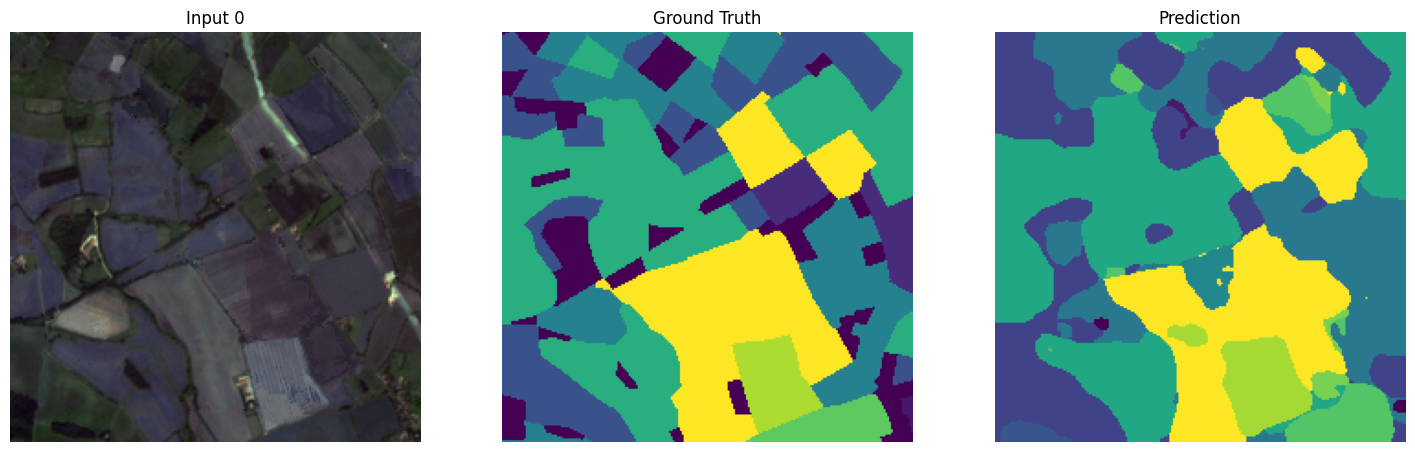

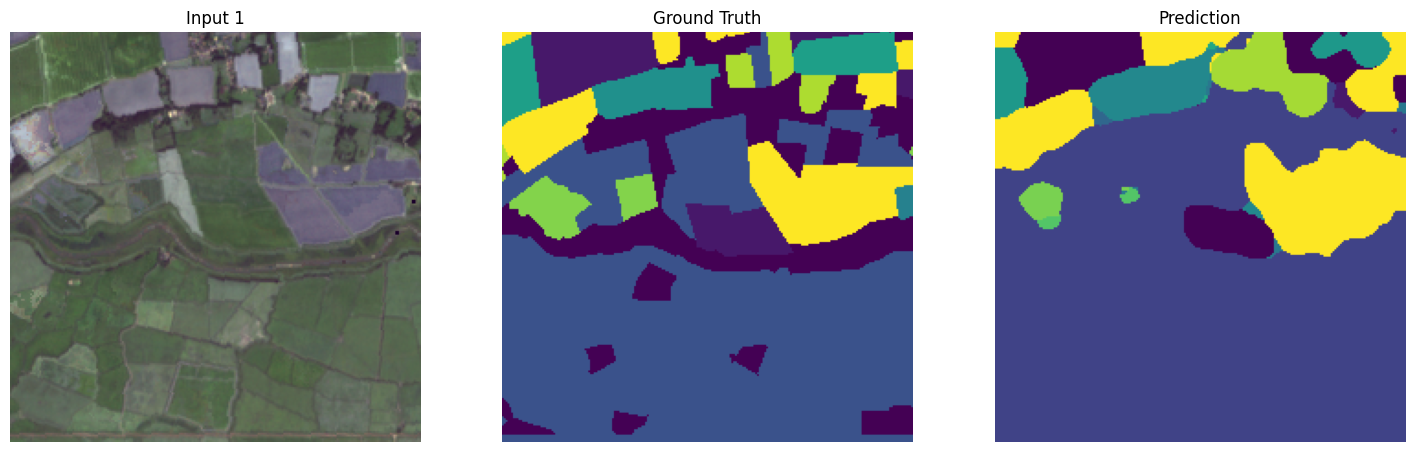

In [ ]:
for i in range(batch["image"].shape[0]):
    fig, ax = plt.subplots(1, 3, figsize=(18,6))

    rgb = batch["image"][i, 0:3, 2].cpu().numpy().transpose(1,2,0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    ax[0].imshow(rgb)
    ax[0].set_title(f"Input {i}")

    ax[1].imshow(batch["mask"][i].cpu())
    ax[1].set_title("Ground Truth")

    ax[2].imshow(preds[i])
    ax[2].set_title("Prediction")

    for a in ax:
        a.axis("off")

    plt.show()